In [1]:
from pathlib import Path
import os
import sys

# move working directory to project root (parent of notebooks)
project_root = Path.cwd().parent
os.chdir(project_root)

# ensure imports work
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Working directory:", Path.cwd())

Working directory: /Users/ourmangg/Documents/Personal_Project/LLMAgora


# Aggregate analysis

## Load data


In [2]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

AGGREGATE_PKL = Path("outputs/Sweep_6/aggregate_df_max.pkl")
with AGGREGATE_PKL.open("rb") as f:
    aggregate_df = pickle.load(f)


In [3]:
# Shared friendly model-name mapping — used by all plotting cells below.
_FRIENDLY_MODEL_NAMES = {
    "anthropic/claude-opus-4.6": "Claude Opus 4.6",
    "deepseek/deepseek-v3.2": "DeepSeek V3.2",
    "google/gemini-3.1-flash-lite-preview": "Gemini 3.1 Flash-Lite",
    "google/gemini-3.1-pro-preview": "Gemini 3.1 Pro",
    "openai/gpt-5.4": "GPT-5.4",
    "openai/gpt-oss-120b": "GPT-OSS-120B",
    "qwen/qwen3.5-397b-a17b": "Qwen 3.5 397B",
    "x-ai/grok-4": "Grok 4",
    "z-ai/glm-5": "GLM-5",
}


def friendly_model(raw: str) -> str:
    """Return human-readable model name, falling back to the part after '/'."""
    return _FRIENDLY_MODEL_NAMES.get(raw, raw.split("/")[-1] if "/" in raw else raw)


### Dataset overview


In [4]:
print("Loaded:", AGGREGATE_PKL.resolve())
print("Shape:", aggregate_df.shape)
print("Columns:", list(aggregate_df.columns))


Loaded: /Users/ourmangg/Documents/Personal_Project/LLMAgora/outputs/Sweep_6/aggregate_df_max.pkl
Shape: (25, 24)
Columns: ['experiment_index', 'config_fingerprint', 'repeat_count', 'case_ids', 'model', 'incentive_direction', 'incentive_type', 'scenario_id', 'cosine-similarity-self-consistency', 'cosine-similarity-cross-agent-alignment', 'persona-individual-turn-scores', 'persona-cumulative-scores', 'persona-full-debate-scores', 'survey-public', 'survey-private', 'survey-diff-public-minus-private', 'decision-self-consistency', 'decision-cross-agent-alignment', 'decision-self-consistency-all-repeats', 'decision-cross-agent-alignment-all-repeats', 'nli-self-consistency', 'nli-cross-agent-alignment', 'emotion-public-utterances', 'emotion-private-reflections']


#### Model Check

Per **experiment row** (each model × scenario × incentive combo): scenario, incentives, repeat count, inferred debate **rounds**, and whether each **analysis column** looks **complete** (repeat count matches `*-all-repeats` when applicable; turn-aligned series match the inferred round count when we can infer it from decisions/cosine).

In [5]:
from IPython.display import display


def _infer_n_rounds(row: pd.Series) -> int | None:
    """Prefer decision self-consistency alpha debate_turns length, else cosine alpha."""
    for col in ("decision-self-consistency", "cosine-similarity-self-consistency"):
        payload = row.get(col)
        if not isinstance(payload, dict):
            continue
        block = payload.get("alpha") or {}
        if col.startswith("decision"):
            dt = block.get("debate_turns") or []
        else:
            dt = block.get("debate_turn") or []
        if dt:
            return len(dt)
    return None


def _len_ok(seq, n: int | None) -> bool:
    if not seq:
        return False
    if n is None:
        return True
    return len(seq) == n


def _check_all_repeats(row: pd.Series, col: str, rc: int) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or p is None:
        return "no"
    reps = p.get("repeats")
    if reps is None:
        return "n/a"
    return "yes" if len(reps) == int(rc) else f"partial({len(reps)}!={rc})"


def _check_cosine_self(row: pd.Series, n: int | None) -> str:
    p = row.get("cosine-similarity-self-consistency")
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        if not _len_ok(b.get("cosine_similarity") or [], n):
            return "partial" if (b.get("cosine_similarity") or []) else "no"
    return "yes"


def _check_cosine_cross(row: pd.Series, n: int | None) -> str:
    p = row.get("cosine-similarity-cross-agent-alignment")
    if not isinstance(p, dict) or not p:
        return "no"
    for key in ("public alignment", "private alignment"):
        b = p.get(key) or {}
        if not _len_ok(b.get("cosine_similarity") or [], n):
            return "partial" if (b.get("cosine_similarity") or []) else "no"
    return "yes"


def _check_persona_turn(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        for ch in ("public", "private"):
            b = (p.get(agent) or {}).get(ch) or {}
            sc = b.get("persona_score") or []
            if not sc:
                return "partial"
            if n is not None and len(sc) != n:
                return "partial"
    return "yes"


def _check_persona_full(row: pd.Series) -> str:
    p = row.get("persona-full-debate-scores")
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        for ch in ("public", "private"):
            b = (p.get(agent) or {}).get(ch) or {}
            if b.get("score") is None and b.get("standard_error") is None:
                return "partial"
    return "yes"


def _check_decision_self(row: pd.Series, n: int | None) -> str:
    p = row.get("decision-self-consistency")
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        pairs = b.get("prob_decision") or []
        if not pairs:
            return "partial"
        if n is not None and len(pairs) != n:
            return "partial"
    return "yes"


def _check_decision_cross(row: pd.Series, n: int | None) -> str:
    p = row.get("decision-cross-agent-alignment")
    if not isinstance(p, dict) or not p:
        return "no"
    for ch in ("public", "private"):
        b = p.get(ch) or {}
        pairs = b.get("prob_decision") or []
        if not pairs:
            return "partial"
        if n is not None and len(pairs) != n:
            return "partial"
    return "yes"


def _check_nli_block(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    if col == "nli-self-consistency":
        keys = ("alpha", "beta")
    else:
        keys = tuple(p.keys()) if p else ()
    for k in keys:
        b = p.get(k)
        if not isinstance(b, dict):
            continue
        probs = b.get("nli_probabilities") or []
        if not probs:
            return "partial"
        if n is not None and len(probs) != n:
            return "partial"
    return "yes" if keys else "no"


def _check_emotion_block(row: pd.Series, col: str, n: int | None) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    for agent in ("alpha", "beta"):
        b = p.get(agent) or {}
        probs = b.get("emotion_probabilities") or []
        if not probs:
            return "partial"
        if n is not None and len(probs) != n:
            return "partial"
    return "yes"


def _check_survey_nonempty(row: pd.Series, col: str) -> str:
    p = row.get(col)
    if not isinstance(p, dict) or not p:
        return "no"
    return "yes" if len(p) > 0 else "partial"


def _coverage_table_for_display(df: pd.DataFrame) -> pd.DataFrame:
    """Sort by model (then scenario); blank repeated `model` values so the column looks merged."""
    out = df.sort_values(["model", "scenario_id"], kind="stable").reset_index(drop=True)
    if "model" not in out.columns:
        return out
    prev = object()
    names: list[str] = []
    for m in out["model"]:
        if m == prev:
            names.append("")
        else:
            names.append(m)
            prev = m
    out = out.copy()
    out["model"] = names
    return out

def build_analysis_coverage_table(df: pd.DataFrame) -> pd.DataFrame:
    rows_out = []
    for _, row in df.iterrows():
        rc = int(row.get("repeat_count") or 0)
        n_rounds = _infer_n_rounds(row)
        rows_out.append(
            {
                "model": row.get("model"),
                "scenario_id": row.get("scenario_id"),
                "incentive_direction": row.get("incentive_direction"),
                "incentive_type": row.get("incentive_type"),
                "repeat_count": rc,
                "n_rounds": n_rounds if n_rounds is not None else pd.NA,
                "cosine_self": _check_cosine_self(row, n_rounds),
                "cosine_cross": _check_cosine_cross(row, n_rounds),
                "persona_turn": _check_persona_turn(row, "persona-individual-turn-scores", n_rounds),
                "persona_cum": _check_persona_turn(row, "persona-cumulative-scores", n_rounds),
                "persona_full": _check_persona_full(row),
                "survey_pub": _check_survey_nonempty(row, "survey-public"),
                "survey_priv": _check_survey_nonempty(row, "survey-private"),
                "survey_diff": _check_survey_nonempty(row, "survey-diff-public-minus-private"),
                "decision_self": _check_decision_self(row, n_rounds),
                "decision_cross": _check_decision_cross(row, n_rounds),
                "decision_self_repeats": _check_all_repeats(row, "decision-self-consistency-all-repeats", rc),
                "decision_cross_repeats": _check_all_repeats(row, "decision-cross-agent-alignment-all-repeats", rc),
                "nli_self": _check_nli_block(row, "nli-self-consistency", n_rounds),
                "nli_cross": _check_nli_block(row, "nli-cross-agent-alignment", n_rounds),
                "emotion_pub": _check_emotion_block(row, "emotion-public-utterances", n_rounds),
                "emotion_priv": _check_emotion_block(row, "emotion-private-reflections", n_rounds),
            }
        )
    return pd.DataFrame(rows_out)


_coverage = build_analysis_coverage_table(aggregate_df)
_coverage_view = _coverage_table_for_display(_coverage)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
display(_coverage_view)
print(
    "\nLegend: yes = looks complete; no = missing/empty; partial = some data but length/repeat mismatch; "
    "n/a = column has no `repeats` list (decision *-all-repeats only). "
    "Sorted by model; repeated model cells are left blank (merged look). Raw rows: variable `_coverage`."
)


,model,scenario_id,incentive_direction,incentive_type,repeat_count,n_rounds,cosine_self,cosine_cross,persona_turn,persona_cum,persona_full,survey_pub,survey_priv,survey_diff,decision_self,decision_cross,decision_self_repeats,decision_cross_repeats,nli_self,nli_cross,emotion_pub,emotion_priv
0,anthropic/claude-opus-4.6,faculty_manuscript_submission,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
1,,ngo_climate_endorsement,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
2,,promotion_committee,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
3,deepseek/deepseek-v3.2,faculty_manuscript_submission,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
4,,ngo_climate_endorsement,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
5,,promotion_committee,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
6,google/gemini-3.1-flash-lite-preview,faculty_manuscript_submission,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
7,,ngo_climate_endorsement,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
8,,promotion_committee,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes
9,google/gemini-3.1-pro-preview,faculty_manuscript_submission,positive,future,5,5,yes,yes,yes,partial,partial,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes,yes



Legend: yes = looks complete; no = missing/empty; partial = some data but length/repeat mismatch; n/a = column has no `repeats` list (decision *-all-repeats only). Sorted by model; repeated model cells are left blank (merged look). Raw rows: variable `_coverage`.


## 1. Metadata table


In [6]:
from IPython.display import display

aggregate_df.head(5)




,experiment_index,config_fingerprint,repeat_count,case_ids,model,incentive_direction,incentive_type,scenario_id,cosine-similarity-self-consistency,cosine-similarity-cross-agent-alignment,persona-individual-turn-scores,persona-cumulative-scores,persona-full-debate-scores,survey-public,survey-private,survey-diff-public-minus-private,decision-self-consistency,decision-cross-agent-alignment,decision-self-consistency-all-repeats,decision-cross-agent-alignment-all-repeats,nli-self-consistency,nli-cross-agent-alignment,emotion-public-utterances,emotion-private-reflections
0,0,38eda186decb0bec84fd7f80282450791366f6bae7002a...,5,"[67cd161d6802, c6e509e49ece, 40cc9f36405d, d34...",openai/gpt-5.4,positive,future,promotion_committee,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,"{'decision': 'PROMOTE', 'channel_tuple_orderin...","{'decision': 'PROMOTE', 'agent_tuple_ordering'...","{'decision': 'PROMOTE', 'channel_tuple_orderin...","{'decision': 'PROMOTE', 'agent_tuple_ordering'...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'n...","{'public utterances': {'debate_turns': [1, 2, ...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'e...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'e..."
1,1,3349ad8dc4b113c21f76914613af0da08b44bc269a4c8a...,5,"[0a3b33281af2, d1f96dd180ef, c3524656d1ed, cb3...",openai/gpt-5.4,positive,future,ngo_climate_endorsement,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,"{'decision': 'ENDORSE', 'channel_tuple_orderin...","{'decision': 'ENDORSE', 'agent_tuple_ordering'...","{'decision': 'ENDORSE', 'channel_tuple_orderin...","{'decision': 'ENDORSE', 'agent_tuple_ordering'...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'n...","{'public utterances': {'debate_turns': [1, 2, ...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'e...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'e..."
2,2,7866bb1c250787ab03b59c8eac92e9617bc0078dcb53a6...,5,"[fb964ee75366, e1874cc4252d, 31d47926d385, d69...",openai/gpt-5.4,positive,future,faculty_manuscript_submission,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,{'Q1': {'question': 'I agree with the other pa...,"{'decision': 'SUBMIT NOW', 'channel_tuple_orde...","{'decision': 'SUBMIT NOW', 'agent_tuple_orderi...","{'decision': 'SUBMIT NOW', 'channel_tuple_orde...","{'decision': 'SUBMIT NOW', 'agent_tuple_orderi...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'n...","{'public utterances': {'debate_turns': [1, 2, ...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'e...","{'alpha': {'debate_turns': [1, 2, 3, 4, 5], 'e..."
3,3,8d5ed7acf47aae2c7ddcc68375d0814bd2afe0e832c146...,2,"[9a209682528a, e927a1b3c5a4]",openai/gpt-oss-120b,positive,future,promotion_committee,"{'alpha': {'debate_turn': [1, 2, 3, 4, 5], 'co...","{'public alignment': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [1, 2, 3,...","{'alpha': {'public': {'debate_turn': [], 'pers...","{'alpha': {'public': {'score': None, 'standard...",{'Q1': {'question': 'I agree with the other pa...,{'Q1':

### Model Demo

In [7]:
aggregate_df['decision-self-consistency'][0]

{'decision': 'PROMOTE',
 'channel_tuple_ordering': ('public', 'private'),
 'alpha': {'debate_turns': [1, 2, 3, 4, 5],
  'prob_decision': [(1.0, 0.0),
   (1.0, 0.0),
   (1.0, 0.0),
   (1.0, 0.0),
   (1.0, 0.0)],
  'prob_decision_standard_error': [(0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0)]},
 'beta': {'debate_turns': [1, 2, 3, 4, 5],
  'prob_decision': [(1.0, 1.0),
   (1.0, 1.0),
   (1.0, 1.0),
   (1.0, 1.0),
   (1.0, 1.0)],
  'prob_decision_standard_error': [(0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0),
   (0.0, 0.0)]}}

In [8]:
aggregate_df['nli-self-consistency'][0]

{'alpha': {'debate_turns': [1, 2, 3, 4, 5],
  'nli_probabilities': [(0.0006918286759173498,
    0.014353084238246083,
    0.9849551022052765),
   (0.001885944309469778, 0.01793067647377029, 0.9801833748817443),
   (0.0032372856345318723, 0.024207005032803864, 0.9725556969642639),
   (0.0002602253698569257, 0.003260905866045505, 0.9964788734912873),
   (0.0010758356103906408, 0.007625470694620162, 0.9912986874580383)],
  'nli_probabilities_standard_error': [(0.00023915454893048746,
    0.010223201206044114,
    0.010450665807726103),
   (0.0011702519274804357, 0.008426874614569892, 0.00940108642899795),
   (0.0023927647847440604, 0.014532525889624342, 0.01690687164244563),
   (4.348951967103405e-05, 0.0007687026369851322, 0.0008048146215983921),
   (0.0004638065157720892, 0.002226167295618404, 0.0025961836362337286)],
  'nli_tuple_ordering': ('entailment', 'neutral', 'contradiction')},
 'beta': {'debate_turns': [1, 2, 3, 4, 5],
  'nli_probabilities': [(0.8823296576738358,
    0.11721527

In [9]:
aggregate_df['emotion-public-utterances'][0]

{'alpha': {'debate_turns': [1, 2, 3, 4, 5],
  'emotion_probabilities': [(0.002409841027110815,
    0.0005162859975825995,
    0.01915265340358019,
    0.003456738800741732,
    0.9710434436798095,
    0.0013318493263795971,
    0.0020891883177682757),
   (0.00245592228602618,
    0.00039654132560826836,
    0.008807493280619383,
    0.0020987232215702533,
    0.9835768342018127,
    0.0011165995965711772,
    0.0015479090390726924),
   (0.003183194063603878,
    0.0006908300623763352,
    0.018413404747843743,
    0.0023684280226007105,
    0.9723256826400757,
    0.001286286232061684,
    0.0017320871236734092),
   (0.003567291144281626,
    0.0005415194551460445,
    0.01626063622534275,
    0.0038255687803030016,
    0.9729849100112915,
    0.001179230445995927,
    0.0016408485127612949),
   (0.0029710528906434774,
    0.0005698903871234507,
    0.011417194176465273,
    0.0023116455413401127,
    0.9798770427703858,
    0.001201096223667264,
    0.0016520640579983591)],
  'emotion

In [10]:
aggregate_df['emotion-private-reflections'][0]

{'alpha': {'debate_turns': [1, 2, 3, 4, 5],
  'emotion_probabilities': [(0.007564381323754787,
    0.0017429845873266458,
    0.002450828650034964,
    0.0006116059666965157,
    0.9800949335098267,
    0.005224322900176048,
    0.002310966863296926),
   (0.00872081983834505,
    0.0017152774846181274,
    0.0019103146158158779,
    0.00046108293463476,
    0.9797548174858093,
    0.004781812150031328,
    0.0026559182442724705),
   (0.008639899548143148,
    0.0018138174316845834,
    0.0016613771207630635,
    0.00048188138171099124,
    0.9804345726966858,
    0.00431745401583612,
    0.0026510335970669984),
   (0.01350864376872778,
    0.0025556931737810372,
    0.0018612137297168373,
    0.00046704902779310943,
    0.9719734907150268,
    0.0067873015999794,
    0.0028465678449720146),
   (0.007994771655648946,
    0.001714689307846129,
    0.0016352129634469748,
    0.0004121583711821586,
    0.9814978122711182,
    0.004073755815625191,
    0.002671602787449956)],
  'emotion_pro

## Decision stance plotting


### Decision stance heatmap

Same data as above, but **each incentive combo** (`direction` × `type`) uses **two stacked rows**: **public** then **private**. Groups stay ordered **positive → neutral/`None` → negative**; thick lines separate direction blocks. **Columns** are **debate turns**. Two panels: **Alpha** and **Beta**.

**Why colors aren’t always pure ±1:** each cell uses the **mean probability of the positive decision across repeats**. If repeats disagree, **stance = 2p−1** can sit strictly between −1 and +1. The heatmap **defaults to that full range** (no pinning). Pass **`sign_colors=True`** to `plot_decision_stance_heatmap` if you want colors collapsed to **sign** only (solid red/green).

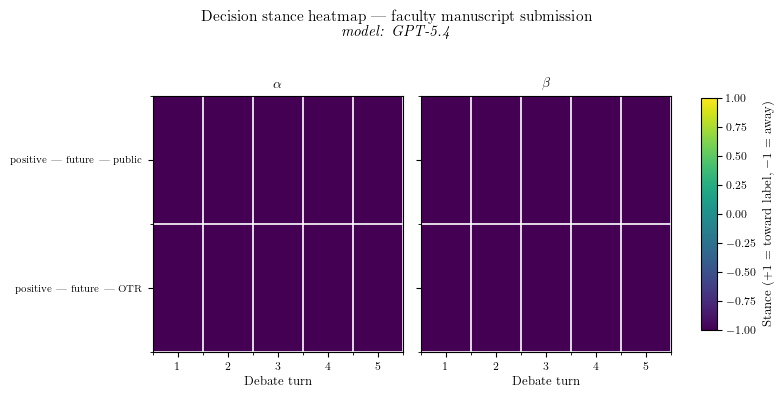

In [11]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_HEATMAP_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}


def _tex_escape_hm(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _prob_to_symmetric_stance(p: float) -> float:
    return 2.0 * float(p) - 1.0


def _direction_sort_key(direction) -> tuple[int, str]:
    if direction is None or (isinstance(direction, float) and pd.isna(direction)):
        return (1, "neutral")
    d = str(direction).lower()
    order = {"positive": 0, "negative": 2}
    return (order.get(d, 1), d)


def _type_sort_key(inc_type) -> tuple[int, str]:
    if inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)):
        return (2, "")
    t = str(inc_type).lower()
    order = {"future": 0, "historical": 1}
    return (order.get(t, 2), t)


def _label_incentive_row(direction, inc_type) -> str:
    d = "None" if direction is None or (isinstance(direction, float) and pd.isna(direction)) else str(direction)
    t = "None" if inc_type is None or (isinstance(inc_type, float) and pd.isna(inc_type)) else str(inc_type)
    return f"{d} | {t}"


def plot_decision_stance_heatmap(
    df: pd.DataFrame,
    *,
    scenario_id: str,
    model: str,
    decision_col: str = "decision-self-consistency",
    sign_colors: bool = False,
) -> None:
    """Heatmap: two rows per incentive combo (public, then OTR), cols = turns."""
    sub = df[(df["scenario_id"] == scenario_id) & (df["model"] == model)].copy()
    if sub.empty:
        print(f"No rows for scenario={scenario_id!r}, model={model!r}")
        return

    sub["_ds"] = sub["incentive_direction"].map(_direction_sort_key)
    sub["_ts"] = sub["incentive_type"].map(_type_sort_key)
    sub = sub.sort_values(by=["_ds", "_ts"], kind="stable").drop(columns=["_ds", "_ts"])

    row_labels: list[str] = []
    turns_template: list[int] | None = None
    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []

    for _, row in sub.iterrows():
        base = _label_incentive_row(row["incentive_direction"], row["incentive_type"])
        payload = row[decision_col]
        if not isinstance(payload, dict):
            row_labels.extend([f"{base} | public", f"{base} | OTR"])
            alpha_mat.append([])
            alpha_mat.append([])
            beta_mat.append([])
            beta_mat.append([])
            continue

        def one_agent_channel(agent: str, channel: int) -> list[float]:
            block = payload.get(agent) or {}
            pairs = block.get("prob_decision") or []
            if not pairs:
                return []
            nonlocal turns_template
            if turns_template is None:
                ts = block.get("debate_turns") or []
                turns_template = list(ts) if ts else list(range(1, len(pairs) + 1))
            return [_prob_to_symmetric_stance(p[channel]) for p in pairs]

        row_labels.append(f"{base} | public")
        row_labels.append(f"{base} | OTR")
        alpha_mat.append(one_agent_channel("alpha", 0))
        alpha_mat.append(one_agent_channel("alpha", 1))
        beta_mat.append(one_agent_channel("beta", 0))
        beta_mat.append(one_agent_channel("beta", 1))

    n_rows = len(row_labels)

    if not turns_template:
        print("No turn data found.")
        return

    n_cols = len(turns_template)

    def pad_rows(mat: list[list[float]]) -> np.ndarray:
        out = np.full((len(mat), n_cols), np.nan, dtype=float)
        for i, row in enumerate(mat):
            for j, v in enumerate(row[:n_cols]):
                out[i, j] = v
        return out

    A = pad_rows(alpha_mat)
    B = pad_rows(beta_mat)

    def _stance_for_color(Z: np.ndarray) -> np.ndarray:
        if not sign_colors:
            return Z
        return np.sign(Z)

    with mpl.rc_context(_HEATMAP_RC):
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(max(8, 1.2 * n_cols), max(4, 0.35 * n_rows + 1.5)),
            sharey=True,
        )
        short_s = _tex_escape_hm(scenario_id.replace("_", " "))
        short_m = _tex_escape_hm(friendly_model(model))

        tex_labels = [_tex_escape_hm(l) for l in row_labels]

        for ax, Z, title in zip(axes, (A, B), (r"$\alpha$", r"$\beta$")):
            Z_show = _stance_for_color(Z)
            im = ax.imshow(
                Z_show,
                aspect="auto",
                cmap="viridis",
                vmin=-1.0,
                vmax=1.0,
                interpolation="nearest",
            )
            ax.set_xticks(np.arange(n_cols))
            ax.set_xticklabels([str(int(turns_template[j])) for j in range(n_cols)])
            ax.set_yticks(np.arange(n_rows))
            ax.set_yticklabels(tex_labels, fontsize=7)
            ax.set_xlabel(r"Debate turn")
            ax.set_title(title)
            ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.2)

        boundaries: list[int] = []
        prev_key: int | None = None
        for i, (_, r) in enumerate(sub.iterrows()):
            key = _direction_sort_key(r["incentive_direction"])[0]
            if prev_key is not None and key != prev_key:
                boundaries.append(i)
            prev_key = key
        for ax in axes:
            for b in boundaries:
                ax.axhline(2 * b - 0.5, color="0.35", linewidth=2.0, clip_on=False)

        fig.suptitle(
            r"Decision stance heatmap --- " + short_s + r" \\" + "\n"
            r"\textit{model: " + short_m + r"}",
            fontsize=11,
        )
        fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.95])
        cax = fig.add_axes([0.88, 0.18, 0.02, 0.58])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"Stance ($+1$ = toward label, $-1$ = away)")
        plt.show()


def plot_decision_analysis(
    df: pd.DataFrame,
    scenario_id: str,
    model: str,
    *,
    decision_col: str = "decision-self-consistency",
    include_heatmap: bool = True,
    heatmap_sign_colors: bool = False,
) -> None:
    """Stance heatmap for one (scenario_id, model) slice."""
    pair = df[(df["scenario_id"] == scenario_id) & (df["model"] == model)]
    if pair.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, model={model!r}.\n"
            f"  scenario_ids: {sorted(df['scenario_id'].dropna().unique())}\n"
            f"  models: {sorted(df['model'].dropna().unique())}"
        )
        return
    if include_heatmap:
        plot_decision_stance_heatmap(
            df,
            scenario_id=scenario_id,
            model=model,
            decision_col=decision_col,
            sign_colors=heatmap_sign_colors,
        )


SCENARIO_ID = "faculty_manuscript_submission"
MODEL = "openai/gpt-5.4"
plot_decision_analysis(aggregate_df, SCENARIO_ID, MODEL)


### Decision stance heatmap (by model, fixed incentive)

Same color scale as above, but you fix **`scenario_id`** and one **incentive combo** (`incentive_direction`, `incentive_type`). **Rows** are **each model**, with **public** then **private**; **columns** are debate turns. **Alpha** and **Beta** are side-by-side panels. Thick lines separate **models**.

In [12]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_HEATMAP_BY_MODEL_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

def _tex_escape_hm2(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _prob_to_symmetric_stance_hm2(p: float) -> float:
    return 2.0 * float(p) - 1.0


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def plot_decision_stance_heatmap_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
    *,
    decision_col: str = "decision-self-consistency",
    sign_colors: bool = False,
) -> None:
    """Heatmap: fixed scenario + incentive combo; rows = model x (pub, otr); cols = turns."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    friendly_names: list[str] = []
    turns_template: list[int] | None = None
    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []

    for model in models:
        row = base[base["model"] == model].iloc[0]
        payload = row[decision_col]
        friendly_names.append(friendly_model(str(model)))

        def channel_row(agent: str, channel: int) -> list[float]:
            nonlocal turns_template
            if not isinstance(payload, dict):
                return []
            block = payload.get(agent) or {}
            pairs = block.get("prob_decision") or []
            if not pairs:
                return []
            if turns_template is None:
                ts = block.get("debate_turns") or []
                turns_template = list(ts) if ts else list(range(1, len(pairs) + 1))
            return [_prob_to_symmetric_stance_hm2(p[channel]) for p in pairs]

        alpha_mat.append(channel_row("alpha", 0))
        alpha_mat.append(channel_row("alpha", 1))
        beta_mat.append(channel_row("beta", 0))
        beta_mat.append(channel_row("beta", 1))

    n_models = len(models)
    n_rows = 2 * n_models
    if not turns_template:
        print("No turn data found.")
        return
    n_cols = len(turns_template)

    def pad_rows(mat: list[list[float]]) -> np.ndarray:
        out = np.full((len(mat), n_cols), np.nan, dtype=float)
        for i, row in enumerate(mat):
            for j, v in enumerate(row[:n_cols]):
                out[i, j] = v
        return out

    A = pad_rows(alpha_mat)
    B = pad_rows(beta_mat)

    def _stance_for_color(Z: np.ndarray) -> np.ndarray:
        if not sign_colors:
            return Z
        return np.sign(Z)

    with mpl.rc_context(_HEATMAP_BY_MODEL_RC):
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(max(8, 1.2 * n_cols), max(4, 0.35 * n_rows + 1.5)),
            sharey=True,
        )

        sub_labels = ["pub", "otr"] * n_models

        for ax, Z, title in zip(axes, (A, B), (r"$\alpha$", r"$\beta$")):
            Z_show = _stance_for_color(Z)
            im = ax.imshow(
                Z_show,
                aspect="auto",
                cmap="viridis",
                vmin=-1.0,
                vmax=1.0,
                interpolation="nearest",
            )
            ax.set_xticks(np.arange(n_cols))
            ax.set_xticklabels([str(int(turns_template[j])) for j in range(n_cols)])
            ax.set_yticks(np.arange(n_rows))
            ax.set_yticklabels(sub_labels, fontsize=7)
            ax.set_xlabel(r"Debate turn")
            ax.set_title(title)
            ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.2)

        for ax in axes:
            for k in range(1, n_models):
                ax.axhline(2 * k - 0.5, color="0.35", linewidth=2.0, clip_on=False)

        for i, fname in enumerate(friendly_names):
            y_center = 2 * i + 0.5
            axes[0].annotate(
                fname,
                xy=(0, y_center),
                xycoords=("axes fraction", "data"),
                xytext=(-8, 0),
                textcoords="offset points",
                ha="right",
                va="center",
                fontsize=7,
                fontweight="bold",
            )

        short_s = scenario_id.replace("_", " ").title()
        inc_dir = "None" if incentive_direction is None else str(incentive_direction)
        inc_tp = "None" if incentive_type is None else str(incentive_type)

        fig.suptitle(
            r"\textbf{Decision stance by model}" + "\n"
            + _tex_escape_hm2(short_s)
            + r" --- incentive: "
            + _tex_escape_hm2(inc_dir) + r", " + _tex_escape_hm2(inc_tp),
            fontsize=11,
        )
        fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.92])
        fig.subplots_adjust(left=0.18)
        cax = fig.add_axes([0.88, 0.18, 0.02, 0.58])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"Stance toward decision label")

        save_dir = Path("outputs/Sweep_6/Saved_plots")
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = f"decision_stance_by_model__{scenario_id}__{inc_dir}__{inc_tp}.pdf".replace(" ", "_")
        fig.savefig(save_dir / fname, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_dir / fname}")

        plt.show()


SCENARIO_ID = "faculty_manuscript_submission"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_decision_stance_heatmap_by_model(
    aggregate_df,
    SCENARIO_ID,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)


NameError: name '_friendly_model' is not defined

### Manual check of the heat map

In [ ]:
# ['promotion_committee', 'ngo_climate_endorsement',
#        ''promotion_committee']

# Top: mean ± SE across repeats (aggregated columns).
# Bottom: each repeat — binary decisions per channel (self-consistency and cross-agent).

mask = (
    (aggregate_df["scenario_id"] == "faculty_manuscript_submission")
    & (aggregate_df["incentive_direction"] == "positive")
    & (aggregate_df["incentive_type"] == "future")
    & (aggregate_df["model"] == "deepseek/deepseek-v3.2")
)
sub = aggregate_df.loc[mask]
if sub.empty:
    print("No rows match; unique models:", aggregate_df["model"].unique())
else:
    row = sub.iloc[0]
    print("repeat_count (analyzed cases):", row.get("repeat_count"))

    sc = row["decision-self-consistency"]
    print("\n=== Aggregated: self-consistency (prob toward label | mean ± SE) ===")
    for agent in ("alpha", "beta"):
        block = sc.get(agent) or {}
        pairs = block.get("prob_decision") or []
        se_pairs = block.get("prob_decision_standard_error") or []
        print(f"\n--- {agent} ---")
        print("  debate_turns:", block.get("debate_turns"))
        print("  public  (avg):", [p[0] for p in pairs])
        print("  private (avg):", [p[1] for p in pairs])
        print("  public  (SE): ", [p[0] for p in se_pairs])
        print("  private (SE): ", [p[1] for p in se_pairs])

    ca = row["decision-cross-agent-alignment"]
    print("\n=== Aggregated: cross-agent (prob alpha vs beta | mean ± SE) ===")
    for channel in ("public", "private"):
        block = ca.get(channel) or {}
        pairs = block.get("prob_decision") or []
        se_pairs = block.get("prob_decision_standard_error") or []
        print(f"\n--- {channel} channel ---")
        print("  debate_turns:", block.get("debate_turns"))
        print("  (alpha, beta) avg per turn:", pairs)
        print("  (alpha, beta) SE  per turn:", se_pairs)

    sc_all = row.get("decision-self-consistency-all-repeats") or {}
    repeats_sc = sc_all.get("repeats") or []
    print(f"\n=== Per-repeat: self-consistency — {len(repeats_sc)} repeat(s) ===")
    for rep in repeats_sc:
        rn = rep.get("repeat_number")
        print(f"\n--- repeat {rn} ---")
        for agent in ("alpha", "beta"):
            for ch_name in ("public", "private"):
                blk = (rep.get(agent) or {}).get(ch_name) or {}
                print(
                    f"  {agent} {ch_name}: turns={blk.get('turns')}, decisions={blk.get('decisions')}"
                )

    ca_all = row.get("decision-cross-agent-alignment-all-repeats") or {}
    repeats_ca = ca_all.get("repeats") or []
    print(f"\n=== Per-repeat: cross-agent — {len(repeats_ca)} repeat(s) ===")
    for rep in repeats_ca:
        rn = rep.get("repeat_number")
        print(f"\n--- repeat {rn} ---")
        for channel in ("public", "private"):
            ch_block = rep.get(channel) or {}
            print(f"  [{channel}]")
            for agent in ("alpha", "beta"):
                blk = ch_block.get(agent) or {}
                print(
                    f"    {agent}: turns={blk.get('turns')}, decisions={blk.get('decisions')}"
                )


## 2. Semantic similarity (cosine, from aggregate table)


### Compare models (fixed scenario + incentives)

Run the next cell and set `SCENARIO_ID`, `INCENTIVE_DIRECTION`, and `INCENTIVE_TYPE` at the top. It plots **alpha** and **beta** cosine self-consistency side by side (1×2), one line per model.

**Single experiment row:** the cell after the comparison plot defines `plot_cosine_from_aggregate_row` using `aggregate_df.iloc[EXPLORER_ROW]`. Columns: `cosine-similarity-self-consistency` and `cosine-similarity-cross-agent-alignment`.


In [ ]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

_COSINE_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
}


def _tex_escape_cos(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


SCENARIO_ID = "promotion_committee"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

_mask = (
    (aggregate_df["scenario_id"] == SCENARIO_ID)
    & (aggregate_df["incentive_direction"] == INCENTIVE_DIRECTION)
    & (aggregate_df["incentive_type"] == INCENTIVE_TYPE)
)
_cosine_subset = aggregate_df.loc[_mask].sort_values("model")

if _cosine_subset.empty:
    raise ValueError(
        f"No rows for scenario_id={SCENARIO_ID!r}, "
        f"incentive_direction={INCENTIVE_DIRECTION!r}, incentive_type={INCENTIVE_TYPE!r}"
    )


def _color_key(model_id: str) -> str:
    s = str(model_id).lower()
    if "gpt" in s:
        return "gpt"
    if "/" in str(model_id):
        return str(model_id).split("/")[0]
    return str(model_id)


_models = sorted(_cosine_subset["model"].unique(), key=str)
_by_key: defaultdict[str, list[str]] = defaultdict(list)
for _m in _models:
    _by_key[_color_key(_m)].append(_m)
for _k in _by_key:
    _by_key[_k].sort()

_variant_index: dict[str, int] = {}
for _ms in _by_key.values():
    for _i, _m in enumerate(_ms):
        _variant_index[_m] = _i

_sorted_keys = sorted(_by_key.keys(), key=lambda x: (x != "gpt", x))
_nk = len(_sorted_keys)
_key_colors = {
    _k: plt.cm.tab20(_i / max(_nk - 1, 1)) if _nk > 1 else plt.cm.tab20(0.0)
    for _i, _k in enumerate(_sorted_keys)
}

_linestyles = ["-", "--", "-.", ":"]
_markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

with mpl.rc_context(_COSINE_RC):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    all_turns: set[int] = set()

    for _, row in _cosine_subset.iterrows():
        _mid = str(row["model"])
        label = _tex_escape_cos(friendly_model(_mid))
        ck = _color_key(_mid)
        color = _key_colors[ck]
        vi = _variant_index[_mid]
        ls = _linestyles[vi % len(_linestyles)]
        mk = _markers[vi % len(_markers)]
        self_c = row["cosine-similarity-self-consistency"]
        for ax_idx, (ax, agent) in enumerate(zip(axes, ("alpha", "beta"))):
            payload = self_c.get(agent)
            if not payload:
                continue
            x = payload["debate_turn"]
            all_turns.update(int(t) for t in x)
            y = np.asarray(payload["cosine_similarity"], dtype=float)
            e = np.asarray(payload["standard_error"], dtype=float)
            plot_label = label if ax_idx == 0 else ""
            ax.errorbar(
                x,
                y,
                yerr=e,
                color=color,
                linestyle=ls,
                marker=mk,
                label=plot_label,
                capsize=2,
                alpha=0.85,
            )

    short_s = _tex_escape_cos(SCENARIO_ID.replace("_", " "))
    short_dir = _tex_escape_cos(INCENTIVE_DIRECTION)
    short_tp = _tex_escape_cos(INCENTIVE_TYPE)

    axes[0].set_title(
        r"$\alpha$ --- cosine self{-}consistency" + "\n"
        + short_s + r" $\cdot$ " + short_dir + r" $\cdot$ " + short_tp
    )
    axes[1].set_title(
        r"$\beta$ --- cosine self{-}consistency" + "\n"
        + short_s + r" $\cdot$ " + short_dir + r" $\cdot$ " + short_tp
    )

    int_turns = sorted(all_turns) if all_turns else [1, 2, 3, 4, 5]

    for ax in axes:
        ax.set_xlabel(r"Debate turn")
        ax.set_ylabel(r"Cosine similarity")
        ax.set_xticks(int_turns)
        ax.set_xticklabels([str(t) for t in int_turns])

    _h, _labs = axes[0].get_legend_handles_labels()
    fig.legend(
        _h, _labs,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        bbox_transform=axes[1].transAxes,
        fontsize=8,
    )
    plt.tight_layout(rect=[0.0, 0.0, 0.82, 1.0])
    plt.show()

print("Models plotted:", len(_cosine_subset), "---", list(_cosine_subset["model"]))


## 3. Persona adherence (serialized nested dicts)


### Serialized nested dict columns

Inspect `persona-individual-turn-scores`, `persona-cumulative-scores`, and `persona-full-debate-scores` 
for the selected row (same structure as produced by `agora.eval_aggregate`).


### Persona adherence heatmap (by model, fixed incentive)

Same layout as **Decision stance heatmap (by model, fixed incentive)** below: fix `scenario_id` and one incentive combo; **rows** are each **model** with **public** then **private**; **columns** are debate turns. **Alpha** and **Beta** are side-by-side panels. Thick lines separate **models**.

Uses **`persona-individual-turn-scores`** by default (per-turn mean adherence). Pass `persona_col="persona-cumulative-scores"` for the running cumulative series. Color scale is **0.5–5.5** (Likert-style scores).

In [ ]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_PERSONA_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

def _tex_escape_pa(s: str) -> str:
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _match_incentive_column_pa(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def plot_persona_adherence_heatmap_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
    *,
    persona_col: str = "persona-individual-turn-scores",
    vmin: float = 0.5,
    vmax: float = 5.5,
) -> None:
    """Heatmap: fixed scenario + incentive combo; rows = model x (pub, otr); cols = turns."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column_pa(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column_pa(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    friendly_names: list[str] = []
    turns_template: list[int] | None = None
    alpha_mat: list[list[float]] = []
    beta_mat: list[list[float]] = []

    for model in models:
        row = base[base["model"] == model].iloc[0]
        payload = row[persona_col]
        friendly_names.append(friendly_model(str(model)))

        def channel_row(agent: str, channel: str) -> list[float]:
            nonlocal turns_template
            if not isinstance(payload, dict):
                return []
            block = payload.get(agent) or {}
            sub = block.get(channel) or {}
            scores = sub.get("persona_score") or []
            if not scores:
                return []
            if turns_template is None:
                ts = sub.get("debate_turn") or []
                turns_template = list(ts) if ts else list(range(1, len(scores) + 1))
            return [float(x) for x in scores]

        alpha_mat.append(channel_row("alpha", "public"))
        alpha_mat.append(channel_row("alpha", "private"))
        beta_mat.append(channel_row("beta", "public"))
        beta_mat.append(channel_row("beta", "private"))

    n_models = len(models)
    n_rows = 2 * n_models
    if not turns_template:
        print("No turn data found.")
        return
    n_cols = len(turns_template)

    def pad_rows(mat: list[list[float]]) -> np.ndarray:
        out = np.full((len(mat), n_cols), np.nan, dtype=float)
        for i, row in enumerate(mat):
            for j, v in enumerate(row[:n_cols]):
                out[i, j] = v
        return out

    A = pad_rows(alpha_mat)
    B = pad_rows(beta_mat)

    with mpl.rc_context(_PERSONA_RC):
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(max(8, 1.2 * n_cols), max(4, 0.35 * n_rows + 1.5)),
            sharey=True,
        )

        sub_labels = ["pub", "otr"] * n_models

        for ax, Z, title in zip(axes, (A, B), (r"$\alpha$", r"$\beta$")):
            im = ax.imshow(
                Z,
                aspect="auto",
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
            )
            ax.set_xticks(np.arange(n_cols))
            ax.set_xticklabels([str(int(turns_template[j])) for j in range(n_cols)])
            ax.set_yticks(np.arange(n_rows))
            ax.set_yticklabels(sub_labels, fontsize=7)
            ax.set_xlabel(r"Debate turn")
            ax.set_title(title)
            ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=1.2)

        for ax in axes:
            for k in range(1, n_models):
                ax.axhline(2 * k - 0.5, color="0.35", linewidth=2.0, clip_on=False)

        for i, fname in enumerate(friendly_names):
            y_center = 2 * i + 0.5
            axes[0].annotate(
                fname,
                xy=(0, y_center),
                xycoords=("axes fraction", "data"),
                xytext=(-8, 0),
                textcoords="offset points",
                ha="right",
                va="center",
                fontsize=7,
                fontweight="bold",
            )

        short_s = scenario_id.replace("_", " ").title()
        inc_dir = "None" if incentive_direction is None else str(incentive_direction)
        inc_tp = "None" if incentive_type is None else str(incentive_type)

        fig.suptitle(
            r"\textbf{Persona adherence by model}" + "\n"
            + _tex_escape_pa(short_s)
            + r" --- incentive: "
            + _tex_escape_pa(inc_dir) + r", " + _tex_escape_pa(inc_tp),
            fontsize=11,
        )
        fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.90])
        fig.subplots_adjust(left=0.18)
        cax = fig.add_axes([0.88, 0.18, 0.02, 0.58])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(r"Persona score (high = strong adherence)")

        save_dir = Path("outputs/Sweep_6/Saved_plots")
        save_dir.mkdir(parents=True, exist_ok=True)
        fname = f"persona_adherence_by_model__{scenario_id}__{inc_dir}__{inc_tp}.pdf".replace(" ", "_")
        fig.savefig(save_dir / fname, bbox_inches="tight", dpi=300)
        print(f"Saved: {save_dir / fname}")

        plt.show()


SCENARIO_ID = "faculty_manuscript_submission"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_persona_adherence_heatmap_by_model(
    aggregate_df,
    SCENARIO_ID,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)


## 4. NLI (mean ± SE from aggregate table)


### NLI stacked bars (by model, fixed incentive)

Fix **`scenario_id`** and one incentive combo. **One row per model**; **two columns**: **Alpha** | **Beta** (self-consistency: private → public NLI), then a second figure for **cross-agent** (**public utterances** | **private reflections**). Each panel is **100% stacked bars** over **debate turn** (entailment / neutral / contradiction from `nli_tuple_ordering`; colors: green / gray / red by label name).


In [ ]:
import os
os.environ.setdefault("PATH", "")
if "/Library/TeX/texbin" not in os.environ["PATH"]:
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_NLI_RC = {
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
}


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def _nli_color(label: str) -> str:
    k = str(label).lower()
    if "entail" in k:
        return "#2ca02c"
    if "contrad" in k:
        return "#d62728"
    if "neutral" in k:
        return "#7f7f7f"
    return "#9467bd"


def _prob_matrix_from_nli_block(block: dict) -> tuple[np.ndarray, list[int], tuple[str, ...]] | None:
    tuples_ = block.get("nli_probabilities") or []
    if not tuples_:
        return None
    ord_ = block.get("nli_tuple_ordering") or ()
    labels = tuple(str(x) for x in ord_) if ord_ else tuple(f"L{i}" for i in range(len(tuples_[0])))
    tt = block.get("debate_turns") or []
    turns = list(tt) if tt else list(range(1, len(tuples_) + 1))
    mat = np.array([[float(t[i]) for i in range(len(labels))] for t in tuples_], dtype=float)
    return mat, turns, labels


def _tex_escape(s: str) -> str:
    """Escape characters that are special in LaTeX."""
    for ch in ("_", "&", "%", "$", "#", "{", "}"):
        s = s.replace(ch, "\\" + ch)
    s = s.replace("-", "{-}")
    return s


def _draw_stacked_nli_bars(
    ax,
    mat: np.ndarray,
    turns: list[int],
    labels: tuple[str, ...],
    *,
    title: str,
    bar_width: float = 0.55,
) -> None:
    n_turns, n_lab = mat.shape
    x = np.arange(n_turns, dtype=float)
    bottom = np.zeros(n_turns)
    for li in range(n_lab):
        h = mat[:, li]
        lab = labels[li]
        ax.bar(
            x,
            h,
            bottom=bottom,
            width=bar_width,
            label=lab,
            color=_nli_color(lab),
            edgecolor="white",
            linewidth=0.3,
        )
        bottom = bottom + h
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(t)) for t in turns])
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel(r"Debate turn")
    ax.set_ylabel(r"Probability")
    ax.set_title(title)
    ax.margins(x=0.12)


def plot_nli_self_consistency_stacked_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
) -> None:
    r"""NLI self-consistency: one row per model; columns $\alpha$ | $\beta$; stacked bars per turn."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    n_m = len(models)
    if n_m == 0:
        print("No models.")
        return

    short_s = scenario_id.replace("_", " ")
    inc_dir = "None" if incentive_direction is None else str(incentive_direction)
    inc_tp = "None" if incentive_type is None else str(incentive_type)

    with mpl.rc_context(_NLI_RC):
        fig, axes = plt.subplots(
            n_m, 2,
            figsize=(7, max(2.4, 1.5 * n_m)),
            sharey=True, squeeze=False,
        )
        for i, model in enumerate(models):
            row = base[base["model"] == model].iloc[0]
            nli = row.get("nli-self-consistency")
            if not isinstance(nli, dict):
                for j in range(2):
                    axes[i, j].text(
                        0.5, 0.5, r"\textit{no NLI data}",
                        ha="center", va="center", transform=axes[i, j].transAxes,
                    )
                continue
            for j, (agent, title) in enumerate((
                ("alpha", r"$\alpha$ (NLI self)"),
                ("beta",  r"$\beta$ (NLI self)"),
            )):
                ax = axes[i, j]
                block = nli.get(agent) or {}
                got = _prob_matrix_from_nli_block(block)
                if got is None:
                    ax.text(
                        0.5, 0.5, r"\textit{no data}",
                        ha="center", va="center", transform=ax.transAxes,
                    )
                    ax.set_title(title)
                    continue
                mat, turns, labels = got
                _draw_stacked_nli_bars(ax, mat, turns, labels, title=title)
            axes[i, 0].set_ylabel(
                r"\textbf{" + _tex_escape(friendly_model(str(model))) + "}",
                fontsize=8,
            )

        handles, legend_labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(
            handles, legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=len(legend_labels),
            framealpha=0.9,
            handlelength=1.0,
            handletextpad=0.4,
            borderpad=0.3,
        )
        fig.suptitle(
            r"NLI self-consistency (private $\rightarrow$ public) --- "
            + short_s.replace("_", r"\_")
            + "\n"
            + r"\small " + inc_dir + r" $\mid$ " + inc_tp,
            fontsize=10,
            y=1.06,
        )
        fig.tight_layout()
        plt.show()


def plot_nli_cross_agent_stacked_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
) -> None:
    r"""NLI cross-agent: one row per model; public utterances | private reflections."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    n_m = len(models)
    if n_m == 0:
        print("No models.")
        return

    short_s = scenario_id.replace("_", " ")
    inc_dir = "None" if incentive_direction is None else str(incentive_direction)
    inc_tp = "None" if incentive_type is None else str(incentive_type)

    cross_keys = ("public utterances", "private reflections")
    with mpl.rc_context(_NLI_RC):
        fig, axes = plt.subplots(
            n_m, 2,
            figsize=(7, max(2.4, 1.5 * n_m)),
            sharey=True, squeeze=False,
        )
        for i, model in enumerate(models):
            row = base[base["model"] == model].iloc[0]
            nli_x = row.get("nli-cross-agent-alignment")
            if not isinstance(nli_x, dict):
                for j in range(2):
                    axes[i, j].text(
                        0.5, 0.5, r"\textit{no NLI data}",
                        ha="center", va="center", transform=axes[i, j].transAxes,
                    )
                continue
            for j, (ckey, ctitle) in enumerate(zip(cross_keys, (
                r"Cross-agent --- public",
                r"Cross-agent --- private",
            ))):
                ax = axes[i, j]
                block = nli_x.get(ckey) or {}
                got = _prob_matrix_from_nli_block(block)
                if got is None:
                    ax.text(
                        0.5, 0.5, r"\textit{no data}",
                        ha="center", va="center", transform=ax.transAxes,
                    )
                    ax.set_title(ctitle)
                    continue
                mat, turns, labels = got
                _draw_stacked_nli_bars(ax, mat, turns, labels, title=ctitle)
            axes[i, 0].set_ylabel(
                r"\textbf{" + _tex_escape(friendly_model(str(model))) + "}",
                fontsize=8,
            )

        handles, legend_labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(
            handles, legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.0),
            ncol=len(legend_labels),
            framealpha=0.9,
            handlelength=1.0,
            handletextpad=0.4,
            borderpad=0.3,
        )
        fig.suptitle(
            r"NLI cross-agent --- "
            + short_s.replace("_", r"\_")
            + "\n"
            + r"\small " + inc_dir + r" $\mid$ " + inc_tp,
            fontsize=10,
            y=1.06,
        )
        fig.tight_layout()
        plt.show()


# --- edit scenario + incentives, then run ---
SCENARIO_ID = "promotion_committee"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_nli_self_consistency_stacked_by_model(
    aggregate_df,
    SCENARIO_ID,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)
# plot_nli_cross_agent_stacked_by_model(
#     aggregate_df,
#     SCENARIO_ID,
#     INCENTIVE_DIRECTION,
#     INCENTIVE_TYPE,
# )


## 5. Emotions


### Emotion stacked bars (public \| private per turn, by model)

Fix **`SCENARIO_ID`**, **`INCENTIVE_DIRECTION`**, **`INCENTIVE_TYPE`** (same as other comparison cells). **One row per model**; **two columns** **Alpha** \| **Beta**. In each panel, at every debate turn there are **two** 100% stacked bars side by side: **public** utterances (`emotion-public-utterances`) vs **private** reflections (`emotion-private-reflections`). Colors match across public/private for each emotion label (`emotion_tuple_ordering`).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


def _emotion_matrix_from_block(block: dict) -> tuple[np.ndarray, list[int], tuple[str, ...]] | None:
    tuples_ = block.get("emotion_probabilities") or []
    if not tuples_:
        return None
    ord_ = block.get("emotion_tuple_ordering") or ()
    labels = tuple(str(x) for x in ord_) if ord_ else tuple(f"E{i}" for i in range(len(tuples_[0])))
    tt = block.get("debate_turns") or []
    turns = list(tt) if tt else list(range(1, len(tuples_) + 1))
    mat = np.array([[float(t[i]) for i in range(len(labels))] for t in tuples_], dtype=float)
    return mat, turns, labels


def _draw_grouped_public_private_stacks(
    ax,
    mat_pub: np.ndarray,
    mat_priv: np.ndarray,
    turns: list[int],
    labels: tuple[str, ...],
    *,
    title: str,
) -> None:
    n_turns = mat_pub.shape[0]
    n_lab = mat_pub.shape[1]
    assert mat_priv.shape[0] == n_turns and mat_priv.shape[1] == n_lab
    x = np.arange(n_turns, dtype=float)
    w = 0.38
    pub_x = x - w / 2
    priv_x = x + w / 2
    bottom_p = np.zeros(n_turns)
    bottom_q = np.zeros(n_turns)
    _cm = plt.colormaps["tab20"]
    for li in range(n_lab):
        lab = labels[li]
        c = _cm(li / max(n_lab - 1, 1)) if n_lab > 1 else _cm(0.5)
        ax.bar(
            pub_x,
            mat_pub[:, li],
            w,
            bottom=bottom_p,
            color=c,
            label=lab,
            edgecolor="white",
            linewidth=0.25,
        )
        ax.bar(
            priv_x,
            mat_priv[:, li],
            w,
            bottom=bottom_q,
            color=c,
            label="_nolegend_",
            edgecolor="white",
            linewidth=0.25,
        )
        bottom_p = bottom_p + mat_pub[:, li]
        bottom_q = bottom_q + mat_priv[:, li]
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(t)) for t in turns])
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("debate turn  (left stack = public, right = private)")
    ax.set_ylabel("probability")
    ax.set_title(title)


def plot_emotion_public_private_stacked_by_model(
    df: pd.DataFrame,
    scenario_id: str,
    incentive_direction,
    incentive_type,
) -> None:
    """Per model: Alpha | Beta; each panel = grouped stacked bars (public | private) per turn."""
    base = df[df["scenario_id"] == scenario_id].copy()
    base = base[_match_incentive_column(base["incentive_direction"], incentive_direction)]
    base = base[_match_incentive_column(base["incentive_type"], incentive_type)]
    if base.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return

    models = sorted(base["model"].dropna().unique(), key=str)
    n_m = len(models)
    if n_m == 0:
        print("No models.")
        return

    short_s = scenario_id.replace("_", " ")
    inc_dir = "None" if incentive_direction is None else str(incentive_direction)
    inc_tp = "None" if incentive_type is None else str(incentive_type)

    fig, axes = plt.subplots(n_m, 2, figsize=(13, max(3.0, 2.3 * n_m)), sharey=True, squeeze=False)
    for i, model in enumerate(models):
        row = base[base["model"] == model].iloc[0]
        pub_all = row.get("emotion-public-utterances")
        priv_all = row.get("emotion-private-reflections")
        if not isinstance(pub_all, dict) or not isinstance(priv_all, dict):
            for j in range(2):
                axes[i, j].text(0.5, 0.5, "no emotion data", ha="center", va="center", transform=axes[i, j].transAxes)
            continue
        for j, agent in enumerate(("alpha", "beta")):
            ax = axes[i, j]
            pb = pub_all.get(agent) or {}
            vb = priv_all.get(agent) or {}
            gp = _emotion_matrix_from_block(pb)
            gv = _emotion_matrix_from_block(vb)
            if gp is None or gv is None:
                ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(f"{agent} (emotions)")
                continue
            mat_p, turns_p, lab_p = gp
            mat_v, turns_v, lab_v = gv
            n = min(mat_p.shape[0], mat_v.shape[0])
            if lab_p != lab_v:
                ax.text(
                    0.5,
                    0.5,
                    "public/private emotion label order mismatch",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(f"{agent} (emotions)")
                continue
            mat_p = mat_p[:n]
            mat_v = mat_v[:n]
            turns = [turns_p[k] if k < len(turns_p) else turns_v[k] for k in range(n)]
            _draw_grouped_public_private_stacks(
                ax,
                mat_p,
                mat_v,
                turns,
                lab_p,
                title=f"{agent} — public vs private",
            )
        axes[i, 0].set_ylabel(friendly_model(str(model)), fontsize=9, fontweight="bold")

    fig.suptitle(
        f"Emotions (public | private per turn) — {short_s}\n{inc_dir} | {inc_tp}",
        fontsize=11,
        y=0.99,
    )
    leg_h: list = []
    leg_l: list = []
    for ax in np.reshape(axes, (-1,)):
        h, lbl = ax.get_legend_handles_labels()
        leg_h = [hi for hi, li in zip(h, lbl) if li and li != "_nolegend_"]
        leg_l = [li for li in lbl if li and li != "_nolegend_"]
        if leg_l:
            break
    if leg_l:
        fig.legend(
            leg_h,
            leg_l,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=min(len(leg_l), 8),
            fontsize=7,
            framealpha=0.95,
        )
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.92])
    plt.show()


# --- edit scenario + incentives, then run ---
SCENARIO_ID = "promotion_committee"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_emotion_public_private_stacked_by_model(
    aggregate_df,
    SCENARIO_ID,
    INCENTIVE_DIRECTION,
    INCENTIVE_TYPE,
)


### 5b. Emotion plot experiments (minimal)

**Radar / spider** for one `TURN` on **one model** (`MODEL_NAME`) after loading `aggregate_df`: six non-neutral emotions on the axes; neutral probabilities as center text (illustrative cases only).

Uses **`emotion-public-utterances`** and **`emotion-private-reflections`**: each column holds `{alpha: {...}, beta: {...}}` with `emotion_probabilities`, `emotion_tuple_ordering`, `debate_turns`.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    if val is None:
        return series.isna()
    return series == val


EMOTION_COLORS = {
    "anger": "#1f77b4",
    "fear": "#f0ad63",
    "joy": "#d62728",
    "love": "#8c564b",
    "neutral": "#e3a9c3",
    "sadness": "#bcbd22",
    "surprise": "#9edae5",
}


def _emotion_color(label: str) -> str:
    return EMOTION_COLORS.get(str(label).lower(), "#7f7f7f")


def _prob_matrix_from_emotion_block(block: dict):
    tuples_ = block.get("emotion_probabilities") or []
    if not tuples_:
        return None
    ord_ = block.get("emotion_tuple_ordering") or ()
    labels = tuple(str(x) for x in ord_) if ord_ else tuple(f"L{i}" for i in range(len(tuples_[0])))
    tt = block.get("debate_turns")
    turns = list(tt) if tt else list(range(1, len(tuples_) + 1))
    mat = np.array([[float(t[i]) for i in range(len(labels))] for t in tuples_], dtype=float)
    return mat, turns, labels


def _get_emotion_block(row, agent: str, mode: str):
    """Public/private come from separate aggregate columns (not nested under 'emotions')."""
    col = (
        "emotion-public-utterances"
        if str(mode).lower() == "public"
        else "emotion-private-reflections"
    )
    payload = row.get(col)
    if not isinstance(payload, dict):
        return None
    block = payload.get(agent) or {}
    if not block:
        return None
    return _prob_matrix_from_emotion_block(block)


def _reorder_emotions(mat, labels):
    labels_l = [str(x).lower() for x in labels]
    return mat, labels_l


def _split_neutral(mat, labels):
    labels_l = [str(x).lower() for x in labels]
    if "neutral" not in labels_l:
        neutral = np.zeros(mat.shape[0])
        return neutral, mat, labels_l
    j = labels_l.index("neutral")
    neutral = mat[:, j]
    keep_idx = [i for i, lab in enumerate(labels_l) if lab != "neutral"]
    rest = mat[:, keep_idx]
    rest_labels = [labels_l[i] for i in keep_idx]
    return neutral, rest, rest_labels


def _normalize_rows(mat):
    s = mat.sum(axis=1, keepdims=True)
    out = np.divide(mat, s, out=np.zeros_like(mat), where=s > 0)
    return out


In [ ]:
SCENARIO_ID = "promotion_committee"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"
MODEL_NAME = "x-ai/grok-4"  # change to a model id present in `base` (see below)

base = aggregate_df[aggregate_df["scenario_id"] == SCENARIO_ID].copy()
base = base[_match_incentive_column(base["incentive_direction"], INCENTIVE_DIRECTION)]
base = base[_match_incentive_column(base["incentive_type"], INCENTIVE_TYPE)]

if base.empty:
    raise ValueError("No rows for this scenario + incentive filter.")

# Uncomment to list valid model ids:
# print(sorted(base["model"].dropna().unique()))

row = base[base["model"] == MODEL_NAME].iloc[0]


# Tiny debug — uncomment if a block comes back missing
# print(row.keys())
# print(type(row.get("emotion-public-utterances")))
# pub = row.get("emotion-public-utterances") or {}
# print(list((pub.get("alpha") or {}).keys()) if isinstance(pub, dict) else "no public payload")


In [ ]:
_RADAR_AXIS_EMOTIONS = ("anger", "fear", "joy", "love", "sadness", "surprise")


def _normalize_non_neutral_vec(vec: np.ndarray) -> np.ndarray:
    s = float(vec.sum())
    if s <= 0:
        return np.zeros_like(vec)
    return vec / s


def _non_neutral_and_neutral_at_turn(mat, turns, labels, turn: int):
    """One debate turn: six non-neutral probs in fixed order, plus neutral."""
    if turn not in turns:
        return None
    idx = turns.index(turn)
    labels_l = [str(x).lower() for x in labels]
    rowv = mat[idx]
    d = {labels_l[i]: float(rowv[i]) for i in range(len(labels_l))}
    neutral = float(d.get("neutral", 0.0))
    vec = np.array([d.get(e, 0.0) for e in _RADAR_AXIS_EMOTIONS], dtype=float)
    return vec, neutral


def plot_emotions_radar_example(
    row,
    agent="alpha",
    turn=3,
    normalize_non_neutral=True,
    *,
    show_center_neutral=True,
    center_text_fmt=".2f",
    emotion_key="emotions",
):
    """Polar radar over six non-neutral emotions; neutral only as center text.

    Uses only non-neutral emotions on the axes; neutral probability is shown
    separately in the center.  Meant for a handful of illustrative (row, turn)
    cases, not a dense grid over all models and turns.

    Public/private distributions come from ``_get_emotion_block`` (aggregate
    columns ``emotion-public-utterances`` / ``emotion-private-reflections``).
    ``emotion_key`` is unused and kept for API compatibility.
    """
    _ = emotion_key
    got_pub = _get_emotion_block(row, agent, "public")
    got_pri = _get_emotion_block(row, agent, "private")
    if got_pub is None or got_pri is None:
        print("Missing public/private emotion data.")
        return

    mat_pub, turns, labels = got_pub
    mat_pri, _, _ = got_pri

    out_pub = _non_neutral_and_neutral_at_turn(mat_pub, turns, labels, turn)
    out_pri = _non_neutral_and_neutral_at_turn(mat_pri, turns, labels, turn)
    if out_pub is None or out_pri is None:
        print(f"Turn {turn} not found. Available turns: {turns}")
        return

    vec_pub, neu_pub = out_pub
    vec_pri, neu_pri = out_pri

    if normalize_non_neutral:
        vec_pub = _normalize_non_neutral_vec(vec_pub)
        vec_pri = _normalize_non_neutral_vec(vec_pri)
        rmax = 1.0
    else:
        rmax = max(1.0, float(vec_pub.max()), float(vec_pri.max()))

    n_ax = len(_RADAR_AXIS_EMOTIONS)
    # Angles evenly spaced in [0, 2π); offset rotates 0-rad to the top.
    theta = np.linspace(0, 2 * np.pi, n_ax, endpoint=False)

    # Close the polygon by repeating the first point.
    th = np.concatenate([theta, [theta[0]]])
    vpub = np.concatenate([vec_pub, [vec_pub[0]]])
    vpri = np.concatenate([vec_pri, [vec_pri[0]]])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
    ax.set_theta_offset(np.pi / 2)   # 0 rad = top of circle
    ax.set_theta_direction(-1)        # clockwise label order

    ax.plot(th, vpub, color="#1f77b4", linewidth=2.0, label="public")
    ax.fill(th, vpub, color="#1f77b4", alpha=0.22)
    ax.plot(th, vpri, color="#ff7f0e", linewidth=2.0, label="private")
    ax.fill(th, vpri, color="#ff7f0e", alpha=0.14)

    ax.set_xticks(theta)
    ax.set_xticklabels(list(_RADAR_AXIS_EMOTIONS), fontsize=11)
    ax.set_ylim(0, rmax)
    ax.set_yticklabels([])
    ax.grid(True, alpha=0.35)

    if show_center_neutral:
        ax.text(
            0.5, 0.5,
            f"public neutral: {neu_pub:{center_text_fmt}}\nprivate neutral: {neu_pri:{center_text_fmt}}",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=9, color="0.25", linespacing=1.3,
        )

    ax.set_title(
        f"{friendly_model(str(row['model']))} — {agent} — turn {turn}: "
        "non-neutral emotion radar",
        fontsize=12, pad=20,
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), fontsize=10)
    plt.tight_layout()
    plt.show()


In [ ]:
TURN = 3  # illustrative single turn for the radar

plot_emotions_radar_example(row, agent="alpha", turn=TURN)
plot_emotions_radar_example(row, agent="beta", turn=TURN)


## Survey

### Survey diff plot


In [ ]:
aggregate_df['survey-diff-public-minus-private'][0]

In [ ]:
aggregate_df['model'].unique()

In [ ]:
aggregate_df['scenario_id'].unique()

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Column name in aggregate_df (not prompt text; identifier for the analysis artifact).
SURVEY_DIFF_COL = "survey-diff-public-minus-private"


def _match_incentive_column(series: pd.Series, val) -> pd.Series:
    """Align with sweep rows: None matches missing incentive columns (NaN)."""
    if val is None:
        return series.isna()
    return series == val


def _sort_question_keys(keys: list[str]) -> list[str]:
    """Q1, Q2, … Q10 before Q2 if using plain sort; use numeric part."""

    def key_fn(k: str) -> tuple[int, str]:
        m = re.match(r"^Q(\d+)$", k)
        return (int(m.group(1)), k) if m else (10_000, k)

    return sorted(keys, key=key_fn)


def plot_survey_diff_public_minus_private(
    df: pd.DataFrame,
    *,
    scenario_id: str,
    model: str,
    incentive_direction=None,
    incentive_type=None,
) -> None:
    """Line + error bars: public−private survey gap vs turn, alpha vs beta; one subplot per question (n×2 grid)."""
    sub = df[(df["scenario_id"] == scenario_id) & (df["model"] == model)].copy()
    sub = sub[_match_incentive_column(sub["incentive_direction"], incentive_direction)]
    sub = sub[_match_incentive_column(sub["incentive_type"], incentive_type)]
    if sub.empty:
        print(
            f"No rows for scenario_id={scenario_id!r}, model={model!r}, "
            f"incentive_direction={incentive_direction!r}, incentive_type={incentive_type!r}."
        )
        return
    if len(sub) > 1:
        print(f"Multiple ({len(sub)}) rows match; using the first. Refine incentive filters if needed.")
    row = sub.iloc[0]
    payload = row[SURVEY_DIFF_COL]
    if not isinstance(payload, dict) or not payload:
        print(f"No {SURVEY_DIFF_COL!r} dict on this row.")
        return

    q_keys = [k for k in payload if isinstance(payload.get(k), dict)]
    q_keys = _sort_question_keys(q_keys)
    n_q = len(q_keys)
    if not n_q:
        print("No questions in payload.")
        return

    ncols = 2
    nrows = (n_q + ncols - 1) // ncols
    fig_w = 12.0
    fig_h = max(6.0, 2.6 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    axes_flat = np.reshape(axes, (-1,))

    for i, qid in enumerate(q_keys):
        ax = axes_flat[i]
        block = payload[qid]
        grp = block.get("question_group", "")
        qtext = str(block.get("question", qid))
        for agent, style in (("alpha", "-"), ("beta", "--")):
            part = block.get(agent)
            if not isinstance(part, dict):
                continue
            turns = part.get("debate_turn") or []
            scores = part.get("response_score") or []
            se = part.get("standard_error") or []
            if len(turns) != len(scores):
                continue
            if len(se) != len(scores):
                se = [0.0] * len(scores)
            y = np.asarray(scores, dtype=float)
            yerr = np.asarray(se, dtype=float)
            (line,) = ax.plot(turns, y, linestyle=style, marker="o", ms=4, label=agent)
            if np.any(yerr > 0):
                ax.fill_between(
                    turns,
                    y - yerr,
                    y + yerr,
                    alpha=0.2,
                    color=line.get_color(),
                )
        ax.axhline(0.0, color="0.5", linewidth=0.8, linestyle=":")
        ax.set_title(f"{qid} ({grp})\n{qtext[:90]}{'…' if len(qtext) > 90 else ''}", fontsize=8)
        ax.set_xlabel("debate turn")
        ax.set_xticks([int(t) for t in (turns if turns else [])])
        ax.set_xticklabels([str(int(t)) for t in (turns if turns else [])])
        ax.set_ylabel("public − private")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=7)

    for j in range(n_q, len(axes_flat)):
        axes_flat[j].set_visible(False)

    inc_d = "None" if incentive_direction is None else str(incentive_direction)
    inc_t = "None" if incentive_type is None else str(incentive_type)
    fig.suptitle(
        f"Survey gap (public − private) — {scenario_id.replace('_', ' ')}\n"
        f"model: {model}  |  {inc_d} | {inc_t}",
        fontsize=11,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# --- scenario + model + optional incentive (then run this cell) ---
# scenario_id / model: same idea as decision plots (`aggregate_df` uniques).
# incentive_direction: "positive" | "negative" | None; incentive_type: "future" | "historical" | None
# model: any value from aggregate_df["model"].unique(), e.g.:
#   "openai/gpt-5.4", "anthropic/claude-sonnet-4.6"
SCENARIO_ID = "faculty_manuscript_submission"
MODEL = "anthropic/claude-opus-4.6"
INCENTIVE_DIRECTION = "positive"
INCENTIVE_TYPE = "future"

plot_survey_diff_public_minus_private(
    aggregate_df,
    scenario_id=SCENARIO_ID,
    model=MODEL,
    incentive_direction=INCENTIVE_DIRECTION,
    incentive_type=INCENTIVE_TYPE,
)


### Comprehensive survey analysis


#### Setup — Build tidy survey DataFrame

Import the `survey_plotting` module and convert the nested survey dicts
in `aggregate_df` into a long/tidy DataFrame suitable for plotting.


In [ ]:
from survey_plotting import (
    config,
    plots_cross_scenario,
    plots_distribution,
    plots_dynamics,
    plots_summary,
    preprocess,
    summarize,
    utils,
)

tidy_df = preprocess.build_tidy_survey_df(aggregate_df)
problems = preprocess.validate(tidy_df)
if problems:
    print('Validation problems:', problems)
else:
    print(f'Tidy survey DataFrame: {tidy_df.shape[0]:,} rows × {tidy_df.shape[1]} cols')
    print(f'Scenarios : {sorted(tidy_df["scenario"].unique())}')
    print(f'Models    : {tidy_df["model"].nunique()}')
    print(f'Questions : Q{tidy_df["question_number"].min()}–Q{tidy_df["question_number"].max()}')
    print(f'Turns     : {sorted(tidy_df["turn"].unique())}')
tidy_df.head()

#### Scenario & model configuration

Set `SCENARIO` to control which scenario the per-scenario plots target.
Set `MODEL` for single-model or cross-scenario plots.


In [ ]:
SCENARIO = "promotion_committee"
MODEL = "openai/gpt-5.4"

print(f"Scenario : {SCENARIO}")
print(f"Model    : {MODEL}")
print(f"Available scenarios: {sorted(tidy_df['scenario'].unique())}")
print(f"Available models  : {sorted(tidy_df['model'].unique())}")

#### Section A — Sanity-check and structure plots

Verify question/turn coverage and inspect raw score distributions.


In [ ]:
# A1 — Question coverage heatmap
plots_summary.coverage_heatmap(tidy_df, SCENARIO)

In [ ]:
# A2 — Public vs private score distributions (faceted by model)
plots_distribution.public_private_distribution(tidy_df, SCENARIO)

#### Section B — Main cross-model analysis

Core comparison figures: heatmaps, lollipops, violins, dynamics, role asymmetry.


In [ ]:
# B1 — Model × question heatmap: mean SIGNED gap (default)
plots_summary.model_question_heatmap(tidy_df, SCENARIO)

In [ ]:
# B1 — Model × question heatmap: mean ABSOLUTE gap
plots_summary.model_question_heatmap(tidy_df, SCENARIO, metric="gap_abs")

In [ ]:
# B2 — Family-level cross-model lollipop (signed gap)
plots_summary.model_family_lollipop(tidy_df, SCENARIO)

In [ ]:
# B3 — Ranked cumulative divergence (overall + by family)
plots_summary.ranked_model_divergence(tidy_df, SCENARIO, metric="gap_abs")
plots_summary.ranked_model_divergence(tidy_df, SCENARIO, metric="gap_abs", by_family=True)

In [ ]:
# B4 — Turn dynamics by family across models (signed gap)
plots_dynamics.turn_dynamics_by_family(tidy_df, SCENARIO)

In [ ]:
# B5 — Violin plot of gap by model, faceted by family (signed gap)
plots_distribution.gap_violin(tidy_df, SCENARIO)

In [ ]:
# B5 variant — violin split by participant role (alpha/beta rows)
plots_distribution.gap_violin(tidy_df, SCENARIO, split_roles=True)

In [ ]:
# B6 — Role asymmetry dumbbell (alpha vs beta, signed gap)
plots_summary.role_asymmetry_dumbbell(tidy_df, SCENARIO)

In [ ]:
# B7 — Question-level model spread (signed gap)
plots_summary.question_model_spread(tidy_df, SCENARIO)

#### Section C — Focused turn-level analysis

Compact question×turn heatmaps, top-K question traces, peak & persistence.


In [ ]:
# C1 — Question × turn heatmap for a single model (signed gap)
plots_dynamics.model_turn_question_heatmap(tidy_df, SCENARIO, MODEL)

In [ ]:
# C2 — Cross-model family×turn heatmap (one per family, signed gap)
for fam in config.FAMILIES:
    plots_dynamics.cross_model_family_turn_heatmap(tidy_df, SCENARIO, fam)

In [ ]:
# C3 — Top-5 question traces (signed gap)
plots_dynamics.top_k_question_traces(tidy_df, SCENARIO, k=5, metric="gap_signed")

In [ ]:
# C4 — Peak & persistence summary
plots_dynamics.peak_persistence_plot(tidy_df, SCENARIO)

#### Section D — Summary statistics & text summary

Numeric tables and automatically generated interpretive text.


In [ ]:
# Summary statistics table
stats = summarize.compute_summary_stats(tidy_df, SCENARIO)
display(stats.round(3))

# Automated text summary
print()
print(utils.generate_text_summary(tidy_df, SCENARIO))

In [ ]:
# D2 — Box plot of gap by model, faceted by family (signed gap)
plots_distribution.gap_boxplot(tidy_df, SCENARIO)

In [ ]:
# D5 — Public vs private mean dumbbell
plots_distribution.public_private_dumbbell(tidy_df, SCENARIO)

#### Sections E+F — Cross-scenario analysis

Compare a selected model across scenarios at the family level.
Cross-scenario comparisons are structural (question number / family),
not semantic (question text changes by scenario).


In [ ]:
# F1a — Cross-scenario family summary (lollipop, signed gap)
plots_cross_scenario.fixed_model_family_summary(tidy_df, MODEL)

In [ ]:
# F1b — Cross-scenario family summary (heatmap, signed gap)
plots_cross_scenario.fixed_model_family_heatmap(tidy_df, MODEL)

In [ ]:
# F2 — Cross-scenario turn dynamics (signed gap)
plots_cross_scenario.fixed_model_turn_dynamics(tidy_df, MODEL)

#### Plotting runner — generate all figures for a scenario

Generates the full recommended plot bundle (Section E pipeline) and
saves every figure to `outputs/plots/`.


In [ ]:
def run_scenario_bundle(df, scenario, *, save_dir="outputs/plots", show=False):
    """Generate all per-scenario plots and save to disk."""
    from pathlib import Path
    base = Path(save_dir) / "by_scenario" / scenario
    base.mkdir(parents=True, exist_ok=True)

    print(f"Generating bundle for: {scenario}")
    plots_summary.model_question_heatmap(
        df, scenario,
        save_path=base / "model_question_heatmap_signed.png", show=show)
    plots_summary.model_question_heatmap(
        df, scenario, metric="gap_abs",
        save_path=base / "model_question_heatmap_abs.png", show=show)
    plots_summary.model_family_lollipop(
        df, scenario,
        save_path=base / "family_model_lollipop_signed.png", show=show)
    plots_distribution.gap_violin(
        df, scenario,
        save_path=base / "gap_violin_by_model_family_signed.png", show=show)
    plots_dynamics.turn_dynamics_by_family(
        df, scenario,
        save_path=base / "turn_dynamics_family_signed.png", show=show)
    plots_summary.role_asymmetry_dumbbell(
        df, scenario,
        save_path=base / "role_asymmetry_dumbbell_signed.png", show=show)
    plots_dynamics.top_k_question_traces(
        df, scenario, k=5, metric="gap_signed",
        save_path=base / "top_questions_turn_traces_signed.png", show=show)
    plots_summary.ranked_model_divergence(
        df, scenario, metric="gap_abs",
        save_path=base / "ranked_model_divergence.png", show=show)
    plots_dynamics.peak_persistence_plot(
        df, scenario,
        save_path=base / "peak_persistence.png", show=show)

    # appendix: per-model question×turn heatmaps
    app = Path(save_dir) / "appendix" / scenario
    app.mkdir(parents=True, exist_ok=True)
    for mdl in sorted(df[df["scenario"] == scenario]["model"].unique()):
        safe = utils.short_model(mdl).replace("/", "_")
        plots_dynamics.model_turn_question_heatmap(
            df, scenario, mdl, metric="gap_abs",
            save_path=app / f"question_turn_heatmap_{safe}.png", show=show)
    print(f"  Saved to {base}/  and  {app}/")


def run_model_cross_scenario_bundle(df, model, *, save_dir="outputs/plots", show=False):
    """Generate cross-scenario plots for one model."""
    from pathlib import Path
    safe = utils.short_model(model).replace("/", "_")
    base = Path(save_dir) / "by_model" / safe
    base.mkdir(parents=True, exist_ok=True)

    print(f"Cross-scenario bundle for: {model}")
    plots_cross_scenario.fixed_model_family_summary(
        df, model,
        save_path=base / "cross_scenario_family_summary_signed.png", show=show)
    plots_cross_scenario.fixed_model_family_heatmap(
        df, model,
        save_path=base / "cross_scenario_family_heatmap_signed.png", show=show)
    plots_cross_scenario.fixed_model_turn_dynamics(
        df, model,
        save_path=base / "cross_scenario_turn_dynamics_signed.png", show=show)
    print(f"  Saved to {base}/")

In [ ]:
# Run per-scenario bundle for the selected scenario
run_scenario_bundle(tidy_df, SCENARIO, show=True)

# Run cross-scenario bundle for the selected model
run_model_cross_scenario_bundle(tidy_df, MODEL, show=True)

In [ ]:
# Generate bundles for ALL scenarios (saved to disk, not displayed)
for scen in sorted(tidy_df["scenario"].unique()):
    run_scenario_bundle(tidy_df, scen, show=False)

# Cross-scenario bundle for every model
for mdl in sorted(tidy_df["model"].unique()):
    run_model_cross_scenario_bundle(tidy_df, mdl, show=False)

print("\nAll bundles generated.")